# EDA, Cleaning, and Stratified Sampling for diabetic_data.csv

This notebook performs initial cleaning (replace `?` with NaN, remove duplicates, fix dtypes), applies ID mappings from `IDS_mapping.csv`,
creates a stratified 5% unseen sample saved as `processed/unseen_data.csv` (held-out and never used for training), and splits the remaining data into an 80% training set and 20% holdout test set.

Files written: `processed/diabetic_data_cleaned.csv`, `processed/unseen_data.csv`, `processed/train.csv`, `processed/test.csv`.

In [22]:
# Cell 1: imports and paths
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import io, csv
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()  # notebook lives in notebooks/ so parent is project root
DATA_DIR = ROOT / 'dataset'
PROCESSED_DIR = ROOT / 'processed'
OUT_DIR = ROOT / 'outputs'
PROCESSED_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
print('ROOT:', ROOT)
print('DATA_DIR:', DATA_DIR)
print('Processed outputs ->', PROCESSED_DIR)


ROOT: C:\Users\82106\Documents\gruve_assignment
DATA_DIR: C:\Users\82106\Documents\gruve_assignment\dataset
Processed outputs -> C:\Users\82106\Documents\gruve_assignment\processed


In [23]:
def parse_ids_mapping(path):
    """
    Returns:
      dict: { column_name -> { id_string: description_string, ... }, ... }
    """
    path = Path(path)
    text = path.read_text(encoding="utf-8")
    lines = text.splitlines()

    # Group lines into blocks. Treat blank lines or a line that is just "," as separators.
    blocks = []
    cur = []
    for ln in lines:
        if ln.strip() == "" or ln.strip() == ",":
            if cur:
                blocks.append("\n".join(cur))
                cur = []
        else:
            cur.append(ln)
    if cur:
        blocks.append("\n".join(cur))

    mappings = {}
    for block in blocks:
        f = io.StringIO(block)
        reader = csv.reader(f)
        try:
            header = next(reader)
        except StopIteration:
            continue
        if len(header) < 2:
            continue
        key_col = header[0].strip()
        table = {}
        for row in reader:
            if not row or all(not c.strip() for c in row):
                continue
            if len(row) < 2:
                continue
            k = row[0].strip()
            # join the remaining columns as the description (handles commas inside quoted descriptions)
            v = ",".join(row[1:]).strip()
            if k == "":
                continue
            table[str(k)] = v
        mappings[key_col] = table

    return mappings

ids_path = DATA_DIR / 'IDS_mapping.csv'
print('IDS mapping exists?', ids_path.exists())
if ids_path.exists():
    mappings = parse_ids_mapping(ids_path)
    print('Parsed mapping keys:', list(mappings.keys()))
else:
    mappings = {}


IDS mapping exists? True
Parsed mapping keys: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']


In [24]:
# load diabetic_data.csv
data_path = DATA_DIR / 'diabetic_data.csv'
assert data_path.exists(), f'Missing {data_path} - ensure dataset/diabetic_data.csv is present'
df = pd.read_csv(data_path, low_memory=False)
print('Original shape:', df.shape)
df.head()


Original shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [25]:
# Initial cleaning
df = df.replace('?', np.nan)

#Drop exact duplicate rows (if any)
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f'Dropped duplicates: {before-after}')

# Fix dtypes for numeric-looking fields by coercing to numeric where appropriate
num_cols = [
    'time_in_hospital','num_lab_procedures','num_procedures','num_medications',
    'number_outpatient','number_emergency','number_inpatient','number_diagnoses'
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Convert the id columns to nullable integers if present
id_cols = ['admission_type_id','discharge_disposition_id','admission_source_id']
for c in id_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')

# Quick missingness summary
missing = df.isna().sum().sort_values(ascending=False).head(30)
missing


Dropped duplicates: 0


weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

Column: diag_3
Non-null count: 100343, Null count: 1423 (1.40% missing)



,count
diag_3,
250,11555
401,8289
276,5175
428,4577
427,3955
...,...
14,1
750,1
370,1



Unique non-missing values:
['11', '110', '111', '112', '115', '117', '122', '123', '131', '132', '135', '136', '138', '139', '14', '141', '146', '148', '150', '151', '152', '153', '154', '155', '156', '157', '158', '161', '162', '163', '164', '17', '170', '171', '172', '173', '174', '175', '179', '180', '182', '183', '185', '186', '188', '189', '191', '192', '193', '195', '196', '197', '198', '199', '200', '201', '202', '203', '204', '205', '208', '211', '214', '215', '216', '217', '218', '220', '223', '225', '226', '227', '228', '230', '233', '235', '236', '238', '239', '240', '241', '242', '243', '244', '245', '246', '250', '250.01', '250.02', '250.03', '250.1', '250.11', '250.12', '250.13', '250.2', '250.21', '250.22', '250.23', '250.3', '250.31', '250.4', '250.41', '250.42', '250.43', '250.5', '250.51', '250.52', '250.53', '250.6', '250.7', '250.8', '250.81', '250.82', '250.83', '250.9', '250.91', '250.92', '250.93', '251', '252', '253', '255', '256', '258', '259', '260', '261', '

,encounter_id,patient_nbr,diag_3
1,149190,55629189,255
2,64410,86047875,V27
3,500364,82442376,403
4,16680,42519267,250
5,35754,82637451,250
6,55842,84259809,V45
7,63768,114882984,250
8,12522,48330783,38
9,15738,63555939,486
10,28236,89869032,996



Sample rows with missing max_glu_serum:


,encounter_id,patient_nbr,diag_3
0,2278392,8222157,NaN
66,715086,3376278,NaN
192,2595612,89193870,NaN
194,2600796,1451637,NaN
216,2735964,2359485,NaN
249,2913624,5073354,NaN
263,2948334,3425292,NaN
283,3048198,3454722,NaN
286,3052140,3323655,NaN
294,3108096,5832918,NaN


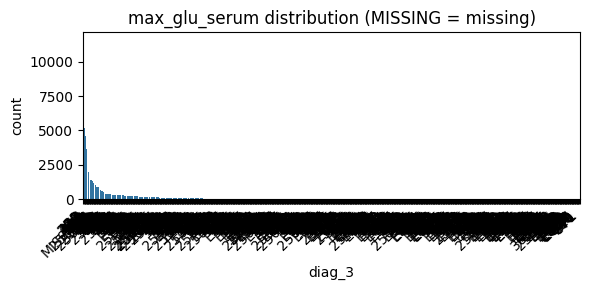

In [26]:
# Inspect column, which has a large number of missing values and may need special handling (e.g. fill with 'None' or drop)
col = 'diag_3'
ser = df[col]

print(f"Column: {col}")
print(f"Non-null count: {ser.notna().sum()}, Null count: {ser.isna().sum()} ({ser.isna().mean():.2%} missing)\n")

# Show value counts (including missing)
s_filled = ser.fillna('MISSING').astype(str)
counts = s_filled.value_counts(dropna=False)
display(counts.to_frame(name='count'))

# Show unique non-missing values
print("\nUnique non-missing values:")
print(sorted(ser.dropna().unique()))

# Show a few example rows with non-missing and missing values
print("\nSample rows with non-missing max_glu_serum:")
display(df[df[col].notna()].loc[:, ['encounter_id', 'patient_nbr', col]].head(10))

print("\nSample rows with missing max_glu_serum:")
display(df[df[col].isna()].loc[:, ['encounter_id', 'patient_nbr', col]].head(10))

# Visualize distribution (save figure)
plt.figure(figsize=(6,3))
order = counts.index.tolist()
sns.countplot(x=s_filled, order=order)
plt.title('max_glu_serum distribution (MISSING = missing)')
plt.xlabel(col)
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

based on the result, 
weight - drop 
max_glu_serum, a1cresult, medical_specialty - fill with unknown 

In [27]:

# weight는 98% missing → 삭제
if "weight" in df.columns:
    df = df.drop(columns=["weight"])

fill_unknown_cols = [
    "max_glu_serum", "A1Cresult",
    "medical_specialty", "payer_code",
    "race", "diag_1", "diag_2", "diag_3"
]

# 결측치 + placeholder 처리
for col in fill_unknown_cols:
    if col in df.columns:
        df[col] = df[col].replace("?", "Unknown")
        df[col] = df[col].fillna("Unknown")

print("\n===== Missing summary after processing =====")
missing = df.isna().sum().sort_values(ascending=False).head(20)
print(missing)


===== Missing summary after processing =====
encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
dtype: int64


In [28]:
# Apply ID mappings 
if mappings:
    for col in id_cols:
        if col in df.columns and col in mappings:
            map_table = mappings[col]
            def mapper(x):
                if pd.isna(x):
                    return np.nan
                try:
                    sx = str(int(x))
                except Exception:
                    sx = str(x)
                return map_table.get(sx, map_table.get(sx.strip(), x))
            df[col + '_mapped'] = df[col].apply(mapper)
    print('Applied mappings for id columns where available.')
else:
    print('No mappings available; skipping mapping step.')

# Save cleaned full dataset
cleaned_path = PROCESSED_DIR / 'diabetic_data_cleaned.csv'
df.to_csv(cleaned_path, index=False)
print('Saved cleaned dataset to', cleaned_path)
df.shape


Applied mappings for id columns where available.
Saved cleaned dataset to C:\Users\82106\Documents\gruve_assignment\processed\diabetic_data_cleaned.csv


(101766, 52)

In [29]:
# Columns to convert to categorical
categorical_features = [
    "number_emergency",
    "num_medications",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

# Convert numeric-looking categorical columns to string
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Quick check
df[categorical_features].dtypes

number_emergency            object
num_medications             object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
dtype: object

In [30]:
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 52 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   encounter_id                     101766 non-null  int64 
 1   patient_nbr                      101766 non-null  int64 
 2   race                             101766 non-null  object
 3   gender                           101766 non-null  object
 4   age                              101766 non-null  object
 5   admission_type_id                101766 non-null  object
 6   discharge_disposition_id         101766 non-null  object
 7   admission_source_id              101766 non-null  object
 8   time_in_hospital                 101766 non-null  int64 
 9   payer_code                       101766 non-null  object
 10  medical_specialty                101766 non-null  object
 11  num_lab_procedures               101766 non-null  int64 
 12  num_procedures  

In [31]:
# Convert object columns to category dtype to save memory
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

#double check
if "weight" in df.columns:
    df = df.drop(columns=["weight"])
# sparse cols that are numeric but have few unique values to save memory 
df['number_emergency'] = df['number_emergency'].astype(int)
df['number_outpatient'] = df['number_outpatient'].astype(int)
df['number_inpatient'] = df['number_inpatient'].astype(int)

df['number_emergency_bin'] = (df['number_emergency'] > 0).astype('int')
df['number_outpatient_bin'] = (df['number_outpatient'] > 0).astype('int')
df['number_inpatient_bin'] = (df['number_inpatient'] > 0).astype('int')

In [32]:
from sklearn.preprocessing import LabelEncoder

def encode_high_card_cols(train_df, unseen_df, cols):
    """High-cardinality columns safe Label Encoding for train + unseen"""
    encoders = {}
    for c in cols:
        le = LabelEncoder()
        # train에서 fit & transform
        train_df[c + '_enc'] = le.fit_transform(train_df[c].astype(str))
        # unseen에서는 transform만, unseen에 없는 값은 -1 처리
        unseen_df[c + '_enc'] = unseen_df[c].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
        encoders[c] = le
    return train_df, unseen_df, encoders

In [33]:
# Create an EXACT 5% stratified sample by readmitted to be saved as unseen_data.csv
# compute sample size as nearest integer to 5% of the cleaned dataset
n = len(df)
sample_size = int(round(n * 0.05))
print(f'Total rows: {n}, 5% sample size: {sample_size}')

# Ensure target column exists
target = 'readmitted'
if target not in df.columns:
    raise ValueError(f'Target column not found in data')

value_counts = df[target].value_counts()
print('Target class counts:', value_counts.to_dict())

min_count = value_counts.min()
stratify_ok = min_count >= 1 and sample_size >= len(value_counts)

if stratify_ok:
    try:
        # use train_test_split with train_size set to sample_size and stratify by target
        sample_df, remaining = train_test_split(df, train_size=sample_size, stratify=df[target], random_state=42)
        print('Stratified sample created.')
    except Exception as e:
        print('Stratified sampling failed:', e)
        sample_df = df.sample(n=sample_size, random_state=42)
        remaining = df.drop(sample_df.index)
        print('Fell back to random sampling.')
else:
    print('Not enough samples per class for stratification; performing random sampling instead.')
    sample_df = df.sample(n=sample_size, random_state=42)
    remaining = df.drop(sample_df.index)


# Save unseen sample
unseen_path = PROCESSED_DIR / 'unseen_data.csv'


high_card_cols = ['diag_1','diag_2','diag_3']
remaining_df, sample_df, encoders = encode_high_card_cols(remaining, sample_df, high_card_cols)


sample_df.to_csv(unseen_path, index=False)
print('Saved unseen sample to', unseen_path)

print('Remaining shape:', remaining_df.shape)

# show the stratified proportions (approx)
print('unseen class distribution:', sample_df[target].value_counts(normalize=True).to_dict())
print('remaining class distribution:', remaining_df[target].value_counts(normalize=True).to_dict())


Total rows: 101766, 5% sample size: 5088
Target class counts: {'NO': 54864, '>30': 35545, '<30': 11357}
Stratified sample created.
Saved unseen sample to C:\Users\82106\Documents\gruve_assignment\processed\unseen_data.csv
Remaining shape: (96678, 58)
unseen class distribution: {'NO': 0.5391116352201258, '>30': 0.3492531446540881, '<30': 0.11163522012578617}
remaining class distribution: {'NO': 0.5391195515008586, '>30': 0.34928318748836346, '<30': 0.11159726101077805}


In [34]:

# Split remaining 95% into 80% train and 20% holdout test 

test_frac = 0.2

try:
    train_df, test_df = train_test_split(remaining_df, test_size=test_frac, stratify=remaining_df[target], random_state=42)
    print('Performed stratified 80/20 split on remaining data.')
except Exception as e:
    print('Stratified split failed, falling back to random split:', e)
    train_df = remaining_df.sample(frac=0.8, random_state=42)
    test_df = remaining_df.drop(train_df.index)

print('Train shape:', train_df.shape, 'Test shape:', test_df.shape)
print('Train class distribution:', train_df[target].value_counts(normalize=True).to_dict())
print('Test class distribution:', test_df[target].value_counts(normalize=True).to_dict())


# Save train/test
train_path = PROCESSED_DIR / 'train.csv'
test_path = PROCESSED_DIR / 'test.csv'


train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)
print('Saved train to', train_path)
print('Saved test to', test_path)


Performed stratified 80/20 split on remaining data.
Train shape: (77342, 58) Test shape: (19336, 58)
Train class distribution: {'NO': 0.5391249256548835, '>30': 0.34927982208890385, '<30': 0.11159525225621267}
Test class distribution: {'NO': 0.5390980554406288, '>30': 0.34929664873810506, '<30': 0.11160529582126603}
Saved train to C:\Users\82106\Documents\gruve_assignment\processed\train.csv
Saved test to C:\Users\82106\Documents\gruve_assignment\processed\test.csv



===== Numeric columns summary =====


,count,mean,std,min,25%,50%,75%,max
encounter_id,77342.0,1.653269e+08,1.027365e+08,12522.0,85227667.5,152426781.0,2.303259e+08,443867222.0
patient_nbr,77342.0,5.431066e+07,3.868145e+07,135.0,23417248.5,45502816.5,8.751201e+07,189502619.0
time_in_hospital,77342.0,4.396499e+00,2.986254e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,77342.0,4.308482e+01,1.970507e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,77342.0,1.341742e+00,1.705092e+00,0.0,0.0,1.0,2.000000e+00,6.0
number_outpatient,77342.0,3.685449e-01,1.289388e+00,0.0,0.0,0.0,0.000000e+00,42.0
number_emergency,77342.0,1.973443e-01,9.373858e-01,0.0,0.0,0.0,0.000000e+00,76.0
number_inpatient,77342.0,6.327998e-01,1.261338e+00,0.0,0.0,0.0,1.000000e+00,21.0
number_diagnoses,77342.0,7.419604e+00,1.933548e+00,1.0,6.0,8.0,9.000000e+00,16.0
number_emergency_bin,77342.0,1.109229e-01,3.140387e-01,0.0,0.0,0.0,0.000000e+00,1.0



===== Categorical columns summary =====


,count,unique,top,freq
race,77342,6,Caucasian,57860
gender,77342,3,Female,41561
age,77342,10,[70-80),19834
admission_type_id,77342,8,1,41018
discharge_disposition_id,77342,26,1,45768
admission_source_id,77342,17,7,43613
payer_code,77342,18,Unknown,30596
medical_specialty,77342,73,Unknown,37946
num_medications,77342,75,12,4625
diag_1,77342,693,428,5175


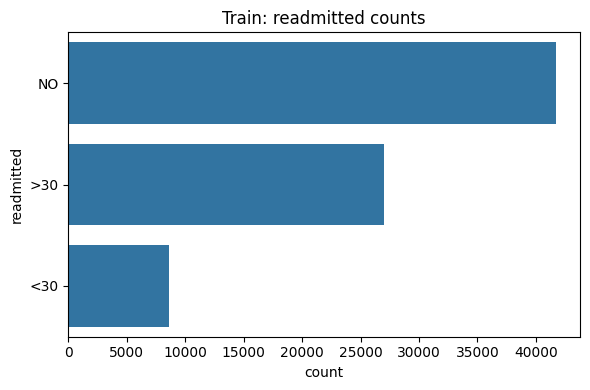

In [35]:
numeric_cols = train_df.select_dtypes(include=['number']).columns
categorical_cols = train_df.select_dtypes(exclude=['number']).columns

print("\n===== Numeric columns summary =====")
display(train_df[numeric_cols].describe().transpose())

print("\n===== Categorical columns summary =====")
display(train_df[categorical_cols].describe().transpose())


plt.figure(figsize=(6,4))
sns.countplot(
    y=train_df[target], 
    order=train_df[target].value_counts().index
)
plt.title('Train: readmitted counts')
plt.tight_layout()
plt.show()


# cols_for_missing = train_df.columns[:40] if train_df.shape[1] > 40 else train_df.columns
# plt.figure(figsize=(12,6))
# sns.heatmap(train_df[cols_for_missing].isna(), cbar=False)
# plt.title('Missingness (train set, subset columns)')
# plt.tight_layout()
# plt.show()


In [36]:
print(train_df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
Index: 77342 entries, 74407 to 91184
Data columns (total 58 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   encounter_id                     77342 non-null  int64   
 1   patient_nbr                      77342 non-null  int64   
 2   race                             77342 non-null  category
 3   gender                           77342 non-null  category
 4   age                              77342 non-null  category
 5   admission_type_id                77342 non-null  category
 6   discharge_disposition_id         77342 non-null  category
 7   admission_source_id              77342 non-null  category
 8   time_in_hospital                 77342 non-null  int64   
 9   payer_code                       77342 non-null  category
 10  medical_specialty                77342 non-null  category
 11  num_lab_procedures               77342 non-null  int64   
 12  num_p

Saved outlier summary to C:\Users\82106\Documents\gruve_assignment\outputs\outlier_summary.csv


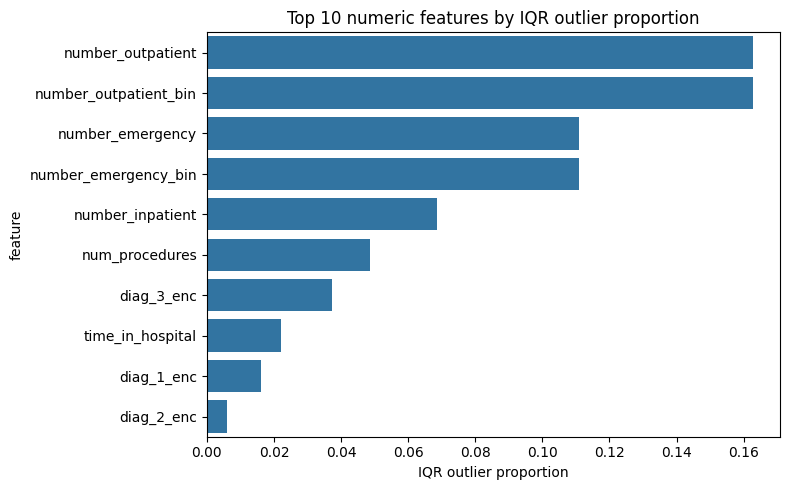

In [37]:
# Outlier detection using IQR and Z-score 
import numpy as np
from scipy import stats

if 'train_df' in globals():
    df_for_out = train_df.copy()
else:
    cleaned_path = PROCESSED_DIR / 'diabetic_data_cleaned.csv'
    assert cleaned_path.exists(), f"Cleaned data not found at {cleaned_path}"
    df_for_out = pd.read_csv(cleaned_path)

numeric_cols = df_for_out.select_dtypes(include=[np.number]).columns.tolist()
# drop obvious identifier columns
numeric_cols = [c for c in numeric_cols if c not in ('encounter_id', 'patient_nbr')]

summary = []
for col in numeric_cols:
    ser = df_for_out[col].dropna()
    if ser.empty:
        continue
    # Z-score method
    z = (ser - ser.mean()) / (ser.std(ddof=0) if ser.std(ddof=0) != 0 else 1)
    z_out = (z.abs() > 3).sum()
    # IQR method
    q1 = ser.quantile(0.25)
    q3 = ser.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_out = ((ser < lower) | (ser > upper)).sum()
    summary.append({
        'feature': col,
        'n_non_missing': int(len(ser)),
        'z_outliers': int(z_out),
        'z_pct': float(z_out / len(ser)),
        'iqr_outliers': int(iqr_out),
        'iqr_pct': float(iqr_out / len(ser))
    })

out_df = pd.DataFrame(summary).sort_values('iqr_pct', ascending=False)
out_df.to_csv(OUT_DIR / 'outlier_summary.csv', index=False)
print('Saved outlier summary to', OUT_DIR / 'outlier_summary.csv')

# Plot top 10 by IQR proportion
if not out_df.empty:
    top10 = out_df.head(10)
    plt.figure(figsize=(8,5))
    sns.barplot(data=top10, x='iqr_pct', y='feature')
    plt.xlabel('IQR outlier proportion')
    plt.title('Top 10 numeric features by IQR outlier proportion')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'figures' / 'outlier_iqr_top10.png')
    plt.show()

# Also save a few outlier rows for the top feature
if not out_df.empty:
    top_feat = out_df.iloc[0]['feature']
    ser = df_for_out[top_feat]
    q1 = ser.quantile(0.25)
    q3 = ser.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_rows = df_for_out[(ser < lower) | (ser > upper)].head(200)
    #if not out_rows.empty:
        #out_rows.to_csv(OUT_DIR / f'outliers_{top_feat}.csv', index=False)
        #print('Saved outlier rows for', top_feat)
else:
    print('No numeric features to analyze for outliers.')


Saved mutual information for numeric features to C:\Users\82106\Documents\gruve_assignment\outputs\mi_numeric.csv


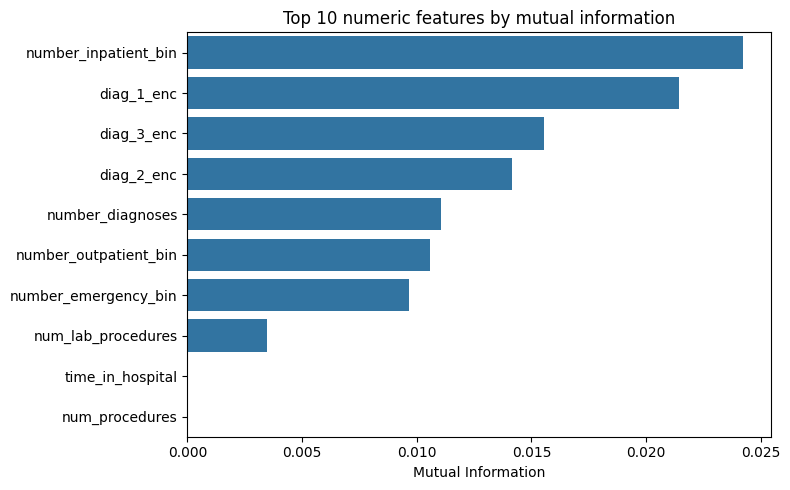

No categorical features suitable for chi2 test found.
Feature importance summaries saved to outputs (mi_numeric.csv, chi2_categorical.csv where applicable).


In [38]:
# Preliminary feature importance: mutual information for numeric, chi2 for categoricals
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# ensure we have train_df
if 'train_df' not in globals():
    train_path = PROCESSED_DIR / 'train.csv'
    assert train_path.exists(), f"Train data not found at {train_path}" 
    train_df = pd.read_csv(train_path)

y = train_df['readmitted']
# encode target to integers for MI/chi2
le_y = LabelEncoder()
try:
    y_enc = le_y.fit_transform(y.astype(str))
except Exception:
    y_enc = y

# numeric mutual information
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ('encounter_id', 'patient_nbr', 'number_emergency', 'number_outpatient', 'number_inpatient')]
mi_results = []
if num_cols:
    X_num = train_df[num_cols].fillna(train_df[num_cols].median())
    try:
        mi = mutual_info_classif(X_num, y_enc, discrete_features=False, random_state=42)
        mi_results = sorted(zip(num_cols, mi), key=lambda x: x[1], reverse=True)
        pd.DataFrame(mi_results, columns=['feature','mi']).to_csv(OUT_DIR / 'mi_numeric.csv', index=False)
        print('Saved mutual information for numeric features to', OUT_DIR / 'mi_numeric.csv')
        # plot top 10
        top10 = mi_results[:10]
        if top10:
            feats, vals = zip(*top10)
            plt.figure(figsize=(8,5))
            sns.barplot(x=list(vals), y=list(feats))
            plt.xlabel('Mutual Information')
            plt.title('Top 10 numeric features by mutual information')
            plt.tight_layout()
            plt.savefig(OUT_DIR / 'figures' / 'mi_numeric_top10.png')
            plt.show()
    except Exception as e:
        print('Mutual information calculation failed:', e)

# categorical chi-squared - pick categorical columns with not too many unique value
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ('readmitted', 'diag_1', 'diag_2', 'diag_3')]
chi_results = []
from sklearn.feature_selection import SelectKBest

# prepare X_cat as encoded integers for chi2
for c in cat_cols:
    nunique = train_df[c].nunique(dropna=True)
    if nunique > 1 and nunique <= 200:  # sensible threshold
        try:
            le = LabelEncoder()
            col_enc = le.fit_transform(train_df[c].fillna('MISSING').astype(str))
            chi, p = chi2(col_enc.reshape(-1,1), y_enc)
            chi_results.append((c, float(chi[0]), float(p[0])))
        except Exception as e:
            # skip columns that fail
            continue

if chi_results:
    chi_df = pd.DataFrame(chi_results, columns=['feature','chi2','pvalue']).sort_values('chi2', ascending=False)
    chi_df.to_csv(OUT_DIR / 'chi2_categorical.csv', index=False)
    print('Saved chi2 results to', OUT_DIR / 'chi2_categorical.csv')
    # plot top 10
    top = chi_df.head(10)
    plt.figure(figsize=(8,5))
    sns.barplot(x='chi2', y='feature', data=top)
    plt.title('Top categorical features by chi2')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'figures' / 'chi2_categorical_top10.png')
    plt.show()
else:
    print('No categorical features suitable for chi2 test found.')

print('Feature importance summaries saved to outputs (mi_numeric.csv, chi2_categorical.csv where applicable).')


In [ ]:
# Drop bottom 10 numeric features by mutual information (least important)
import pandas as pd
import numpy as np
from pathlib import Path
# Load mi_numeric.csv if available
mi_path = OUT_DIR / 'mi_numeric.csv'
if mi_path.exists():
    mi_df = pd.read_csv(mi_path)
    bottom10 = mi_df.sort_values('mi').head(10)['feature'].tolist()
    print('Bottom 10 numeric features (by MI):', bottom10)
else:
    print('mi_numeric.csv not found; computing MI from train_df as fallback')
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.preprocessing import LabelEncoder
    num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ('encounter_id','patient_nbr')]
    X_num = train_df[num_cols].fillna(train_df[num_cols].median())
    y_enc = LabelEncoder().fit_transform(train_df['readmitted'].astype(str))
    mi_vals = mutual_info_classif(X_num, y_enc, discrete_features=False, random_state=42)
    mi_df = pd.DataFrame({'feature':num_cols,'mi':mi_vals}).sort_values('mi')
    bottom10 = mi_df.head(10)['feature'].tolist()
    print('Computed bottom10:', bottom10)
# Drop the features from train_df and test_df (if present)
dropped = []
for c in bottom10:
    if c in train_df.columns:
        train_df.drop(columns=[c], inplace=True)
        dropped.append(c)
    if c in test_df.columns:
        test_df.drop(columns=[c], inplace=True)
print('Dropped features:', dropped)
print('New shapes -> train:', train_df.shape, ' test:', test_df.shape)
# Save reduced datasets for reproducibility
train_df.to_csv(PROCESSED_DIR / 'train_reduced.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_reduced.csv', index=False)
print('Saved reduced train/test to processed/')


In [ ]:
# AutoGluon TabularPredictor: training and evaluation
import os
os.environ['MPLBACKEND'] = 'Agg'  # use non-interactive backend for plots

try:
    from autogluon.tabular import TabularPredictor
except ImportError:
    print("AutoGluon not installed. Install with: pip install autogluon[tabular]")
    raise

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import json

# Load train and test sets (reload if needed)
if 'train_df' not in globals():
    train_path = PROCESSED_DIR / 'train.csv'
    test_path = PROCESSED_DIR / 'test.csv'
    assert train_path.exists() and test_path.exists(), f"Train/test not found"
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

# Prepare data: separate features and target
target = 'readmitted'
##X_train = train_df.drop(columns=[target])
y_train = train_df[target]
#X_test = test_df.drop(columns=[target])
y_test = test_df[target]
drop_cols = ['admission_source_id_mapped','discharge_disposition_id_mapped','admission_type_id_mapped','diag_1', 'diag_2', 'diag_3', 'encounter_id','patient_nbr','number_outpatient','number_inpatient','number_emergency','readmitted']
X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])



print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'Target distribution (train): {y_train.value_counts().to_dict()}')
print(f'Target distribution (test): {y_test.value_counts().to_dict()}')

# Create and train TabularPredictor
predictor_dir = PROCESSED_DIR / 'autogluon_model'
print(f"\nTraining AutoGluon TabularPredictor (saving to {predictor_dir})...")

predictor = TabularPredictor(
    label=target,
    path=str(predictor_dir),
    problem_type='multiclass',
    eval_metric='balanced_accuracy'
)

# Train with a reasonable time limit (adjust as needed)
predictor.fit(
    train_data=train_df,
    time_limit=3600,  # 10 minutes; increase for better models
    presets='best_quality',  # or 'high_quality', 'good_quality'
    verbosity=2,
    ag_args_fit={'class_weight': 'balanced'}
)

print("Training complete.")

# Generate and save leaderboard
leaderboard = predictor.leaderboard(train_df, silent=True)
leaderboard_path = OUT_DIR / 'leaderboard.csv'
leaderboard.to_csv(leaderboard_path, index=False)
print(f"\nLeaderboard (top 10):")
print(leaderboard.head(10))
print(f"Saved full leaderboard to {leaderboard_path}")

# Get best model name
best_model_name = predictor.get_model_best()
print(f"\nBest model: {best_model_name}")

# Evaluate on test set
print("\n" + "="*60)
print("EVALUATION ON HOLDOUT TEST SET")
print("="*60)

y_pred = predictor.predict(X_test)
y_pred_proba = predictor.predict_proba(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

# F1 (macro)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
print(f"F1 Score (macro): {f1_macro:.4f}")

# Classification report
print("\nClassification Report (per-class metrics):")
clf_report = classification_report(y_test, y_pred, zero_division=0)
print(clf_report)

# Save classification report to file
clf_report_path = OUT_DIR / 'classification_report.txt'
with open(clf_report_path, 'w') as f:
    f.write("CLASSIFICATION REPORT\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1 Score (macro): {f1_macro:.4f}\n\n")
    f.write(clf_report)
print(f"Saved classification report to {clf_report_path}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

# Plot and save confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
cm_path = OUT_DIR / 'figures' / 'confusion_matrix.png'
plt.savefig(cm_path)
plt.show()
print(f"Saved confusion matrix plot to {cm_path}")

# Save detailed evaluation metrics as JSON
eval_metrics = {
    'best_model': str(best_model_name),
    'accuracy': float(acc),
    'f1_macro': float(f1_macro),
    'test_set_size': int(len(y_test)),
    'target_classes': sorted(y_test.unique().tolist()),
    'class_distribution_test': y_test.value_counts().to_dict(),
    'class_distribution_train': y_train.value_counts().to_dict()
}
metrics_json_path = OUT_DIR / 'evaluation_metrics.json'
with open(metrics_json_path, 'w') as f:
    json.dump(eval_metrics, f, indent=2)
print(f"\nSaved evaluation metrics to {metrics_json_path}")

# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Best model: {best_model_name}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 (macro): {f1_macro:.4f}")
print(f"\nOutputs saved to {OUT_DIR}:")
print(f"  - leaderboard.csv: all trained models ranked by validation performance")
print(f"  - classification_report.txt: per-class precision, recall, F1")
print(f"  - evaluation_metrics.json: summary metrics")
print(f"  - figures/confusion_matrix.png: confusion matrix heatmap")
print(f"\nPredictor saved to: {predictor_dir}")


Verbosity: 2 (Standard Logging)


Train shape: (77342, 46), Test shape: (19336, 46)
Target distribution (train): {'NO': 41697, '>30': 27014, '<30': 8631}
Target distribution (test): {'NO': 10424, '>30': 6754, '<30': 2158}

Training AutoGluon TabularPredictor (saving to C:\Users\82106\Documents\gruve_assignment\processed\autogluon_model)...


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       1.42 GB / 7.87 GB (18.1%)
Disk Space Avail:   196.94 GB / 461.99 GB (42.6%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the da

KeyboardInterrupt: 

In [ ]:
# Fix nullable Int64 dtypes and retry AutoGluon fit with safer presets
import pandas as pd
import traceback
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load train/test if not present
if 'train_df' not in globals() or 'test_df' not in globals():
    train_path = PROCESSED_DIR / 'train.csv'
    test_path = PROCESSED_DIR / 'test.csv'
    assert train_path.exists() and test_path.exists(), 'Train/test CSVs not found; run earlier cells first.'
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

# Detect pandas nullable Int64 dtypes (string representation 'Int64')
int64_nullable_cols = [c for c in train_df.columns if str(train_df[c].dtype) == 'Int64']
print('Nullable Int64 columns detected (will convert to category):', int64_nullable_cols)

# If none found, also check object columns that look numeric (fallback)
if not int64_nullable_cols:
    # sometimes pandas reads Int64 as object; detect columns created earlier as id_cols
    fallback = [c for c in ['admission_type_id','discharge_disposition_id','admission_source_id'] if c in train_df.columns]
    # if these are present and not numeric, mark them
    for c in fallback:
        if str(train_df[c].dtype) not in ('int64','float64','category'):
            int64_nullable_cols.append(c)
    if int64_nullable_cols:
        print('Fallback detected columns to convert:', int64_nullable_cols)

# Convert those columns to categorical (fill NA with -1 then convert to int then category)
for c in int64_nullable_cols:
    try:
        train_df[c] = train_df[c].fillna(-1).astype('int64').astype('category')
        test_df[c] = test_df[c].fillna(-1).astype('int64').astype('category')
        print(f'Converted {c} -> category')
    except Exception as e:
        print(f'Failed converting {c}:', e)
        traceback.print_exc()

# Show small dtype summary
print('\nSample dtypes (converted / nearby columns):')
for c in int64_nullable_cols[:10]:
    print(c, train_df[c].dtype)

# Optional: convert several id-like numeric columns to category to avoid misinterpretation
id_like = [c for c in ['admission_type_id','discharge_disposition_id','admission_source_id'] if c in train_df.columns]
for c in id_like:
    if str(train_df[c].dtype) not in ('category',):
        try:
            train_df[c] = train_df[c].fillna(-1).astype('int64').astype('category')
            test_df[c] = test_df[c].fillna(-1).astype('int64').astype('category')
            print(f'Ensured {c} is category')
        except Exception:
            pass

# Reduce memory by converting object columns with low cardinality to category
for col in train_df.select_dtypes(include='object').columns:
    if train_df[col].nunique(dropna=False) < 200:
        train_df[col] = train_df[col].astype('category')
        test_df[col] = test_df[col].astype('category')

print('\nDtype conversion complete. Starting retry AutoGluon fit with safer settings...')

# Run AutoGluon retry with safer presets
try:
    from autogluon.tabular import TabularPredictor
    retry_predictor_dir = PROCESSED_DIR / 'autogluon_model_retry'
    predictor = TabularPredictor(label='readmitted', path=str(retry_predictor_dir), problem_type='multiclass', eval_metric='balanced_accuracy')
    # Use safer presets and disable dynamic stacking to avoid DyStack overhead
    predictor.fit(
        train_data=train_df,
        time_limit=2400,            # 40 minutes (adjust if you want longer)
        presets='high_quality',     # safer than 'best_quality'
        verbosity=2,
        dynamic_stacking=False
    )
    print('\nRetry fit complete. Leaderboard top 10:')
    lb = predictor.leaderboard(train_df, silent=True)
    print(lb.head(10))
except Exception as e:
    print('Retry training failed with exception:')
    traceback.print_exc()
    raise

# Save the modified train/test back (optional) so later cells use updated dtypes
train_df.to_csv(PROCESSED_DIR / 'train_converted.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_converted.csv', index=False)
print('Saved converted train/test to processed/train_converted.csv and processed/test_converted.csv')
